# Load fMRI Data

In [1]:
import sys
import os

src_path = os.path.abspath(os.path.join('..', 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)
    
from Load_MRI_Data import *

[get_dataset_dir] Dataset found in C:\Users\JINHWA\nilearn_data\aal_SPM12


In [2]:
male_ids = [100206, 102109, 131823, 112112, 130114, 101410, 102715, 100610, 101309, 102513, 103111]
female_ids = [102311, 100307, 111211, 102816, 128026, 105014, 106521, 107018, 108323, 111009]

subject_ids = male_ids + female_ids

In [5]:
for subject in subject_ids:
    corr_matrices = load_MRI_data(
                                  subject_id = subject, 
                                  run_label  = "REST1_LR",
                                  trim       = 60,
                                  win_size   = 60,
                                  step_size  = 1
                                  )
    
    corr_vectors = vectorize_upper_triangular(corr_matrices)
    corr_vectors_T = corr_vectors.T
    
    OUT_DIR = Path("../Usedata/rfMRI_ts")
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    
    txtfile = OUT_DIR / f"{subject:06d}_REST1_LR_AAL_corr_vec.txt"
    np.savetxt(txtfile, corr_vectors_T, fmt='%.6f')
    
    print(f"Saved {subject} 6670-D correlation vector series as TXT → {txtfile}")

Extracted time-series shape: (1140, 116)
Saved 102311 6670-D correlation vector series as TXT → ..\Usedata\rfMRI_ts\102311_REST1_LR_AAL_corr_vec.txt
Extracted time-series shape: (1140, 116)
Saved 100307 6670-D correlation vector series as TXT → ..\Usedata\rfMRI_ts\100307_REST1_LR_AAL_corr_vec.txt
Extracted time-series shape: (1140, 116)
Saved 111211 6670-D correlation vector series as TXT → ..\Usedata\rfMRI_ts\111211_REST1_LR_AAL_corr_vec.txt
Extracted time-series shape: (1140, 116)
Saved 102816 6670-D correlation vector series as TXT → ..\Usedata\rfMRI_ts\102816_REST1_LR_AAL_corr_vec.txt
Extracted time-series shape: (1140, 116)
Saved 128026 6670-D correlation vector series as TXT → ..\Usedata\rfMRI_ts\128026_REST1_LR_AAL_corr_vec.txt
Extracted time-series shape: (1140, 116)
Saved 105014 6670-D correlation vector series as TXT → ..\Usedata\rfMRI_ts\105014_REST1_LR_AAL_corr_vec.txt
Extracted time-series shape: (1140, 116)
Saved 106521 6670-D correlation vector series as TXT → ..\Usedata

# For single Subject

In [6]:
subject = 100206

In [7]:
corr_matrices = load_MRI_data(subject, "REST1_LR", 60, 60, 1)

Extracted time-series shape: (1140, 116)


In [8]:
# === Checking correlation matrices ===
d = corr_matrices  # Shape: (n_windows, 116, 116)

results = {
    "num_windows"      : d.shape[0],
    "matrix_shape"     : d.shape[1:],
    "diag_all_one"     : bool(np.allclose(np.diagonal(d, axis1=1, axis2=2), 1.0)),
    "all_symmetric"    : bool(np.allclose(d, np.transpose(d, (0, 2, 1)))),
    "nan_count"        : int(np.isnan(d).sum()),
    "inf_count"        : int(np.isinf(d).sum()),
    "value_min"        : float(np.nanmin(d)),  # Use nan-safe version
    "value_max"        : float(np.nanmax(d)),
}

print("=== Correlation Matrix Diagnostics ===")
for k, v in results.items():
    print(f"{k:20s}: {v}")

=== Correlation Matrix Diagnostics ===
num_windows         : 1081
matrix_shape        : (116, 116)
diag_all_one        : True
all_symmetric       : True
nan_count           : 0
inf_count           : 0
value_min           : -0.7748285531997681
value_max           : 1.0


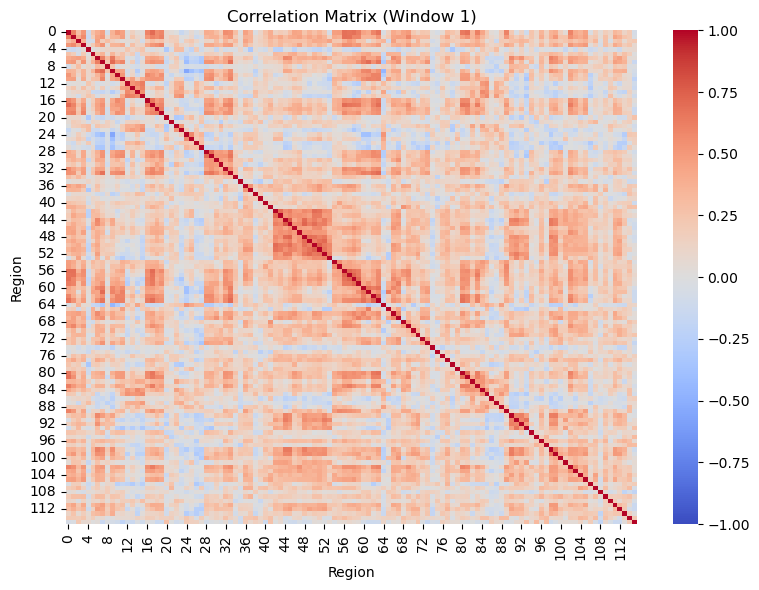

In [9]:
# === Plot sample heatmap ===
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrices[0], cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix (Window 1)")
plt.xlabel("Region")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

In [ ]:
corr_vectors = vectorize_upper_triangular(corr_matrices)

In [ ]:
corr_vectors_T = corr_vectors.T

In [ ]:
# Save corr as TXT
OUT_DIR = Path("../Usedata/rfMRI_ts")
txtfile = OUT_DIR / f"{subject:06d}_REST1_LR_AAL_corr_vec.txt"
np.savetxt(txtfile, corr_vectors_T, fmt='%.6f')
print(f"Saved 6670-D correlation vector series as TXT → {txtfile}")